## Figure 2B: Transcript classification consensus and correctness

The figure describes the number of transcripts that are well classified by all tools, by none tools, or ambiguously classified.

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Make shared utils importable
sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/workflow")
from utils.process_tools import get_classification_scores

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 20)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['figure.constrained_layout.use'] = True

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)

In [ ]:
import matplotlib.font_manager as fm
import os

# Rebuild the font cache
fm.fontManager.addfont(f'/home/{os.getenv("USER")}/.local/share/fonts/Arial.TTF')  # adjust path as needed

# Verify Arial is now available
available_fonts = sorted(set(f.name for f in fm.fontManager.ttflist))
if 'Arial' in available_fonts:
    print("Arial is now available!")
else:
    print("Arial still not found. Check the font file path.")
    print("Available fonts:", available_fonts[:10])

Arial is now available!


## Data loading

In [ ]:
BASE = Path("/mnt/cbib/LNClassifier/paper")
DSET = "gencode.v47.common.cdhit.cv"
#DSET = "gencode.v47"
REFERENCE = "gencode.v47"
AVERAGE = "macro"  # TODO: DOUBLE CHECK

FIGURE_DIR = BASE / 'results' / DSET / 'figures'

tables_dir = BASE / "results" / DSET / "tables"
binary_table_file = tables_dir / f"{DSET}_binary_class_table.tsv"
inference_info_file = BASE / "results" / DSET / "training" / f"{DSET}.inference_info.tsv"

In [ ]:
labels = pd.read_csv(binary_table_file, sep="\t")
labels.columns

Index(['seq_ID', 'fold', 'rnasamba', 'feelnc', 'p_cpat', 'l_cpat', 'lncDC',
       'ss_lncDC', 'mrnn', 'lncrnabert', 'plncpro', 'ss_lncfinder',
       'lncfinder', 'real'],
      dtype='object')

## Ready dataframes

In [ ]:
label_cols = ['rnasamba', 'feelnc', 'l_cpat', 'ss_lncDC', 'mrnn', 'lncrnabert', 'plncpro', 'ss_lncfinder']
correct = pd.DataFrame(index=labels.index)
for c in label_cols:
    correct[c] = labels[c] == labels["real"]

correct["n_correct"] = correct.sum(axis=1)
correct['real'] = labels['real']
correct["n_correct"].value_counts()


n_correct
8    60827
7    26969
6    10302
5     4081
4     2762
3     2257
2     1930
1     1539
0      985
Name: count, dtype: int64

In [ ]:
correct_by_class = correct.groupby("n_correct")["real"].value_counts().unstack().sort_index(ascending=False).rename(columns={True: "coding", False: "lncRNA"})
correct_by_class

real,lncRNA,coding
n_correct,,
8,22240,38587
7,16575,10394
6,2826,7476
5,1218,2863
4,664,2098
3,469,1788
2,479,1451
1,437,1102
0,368,617


## Transcripts by class and number of correct classifications

DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.


/tmp/ipykernel_3106561/4117565621.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


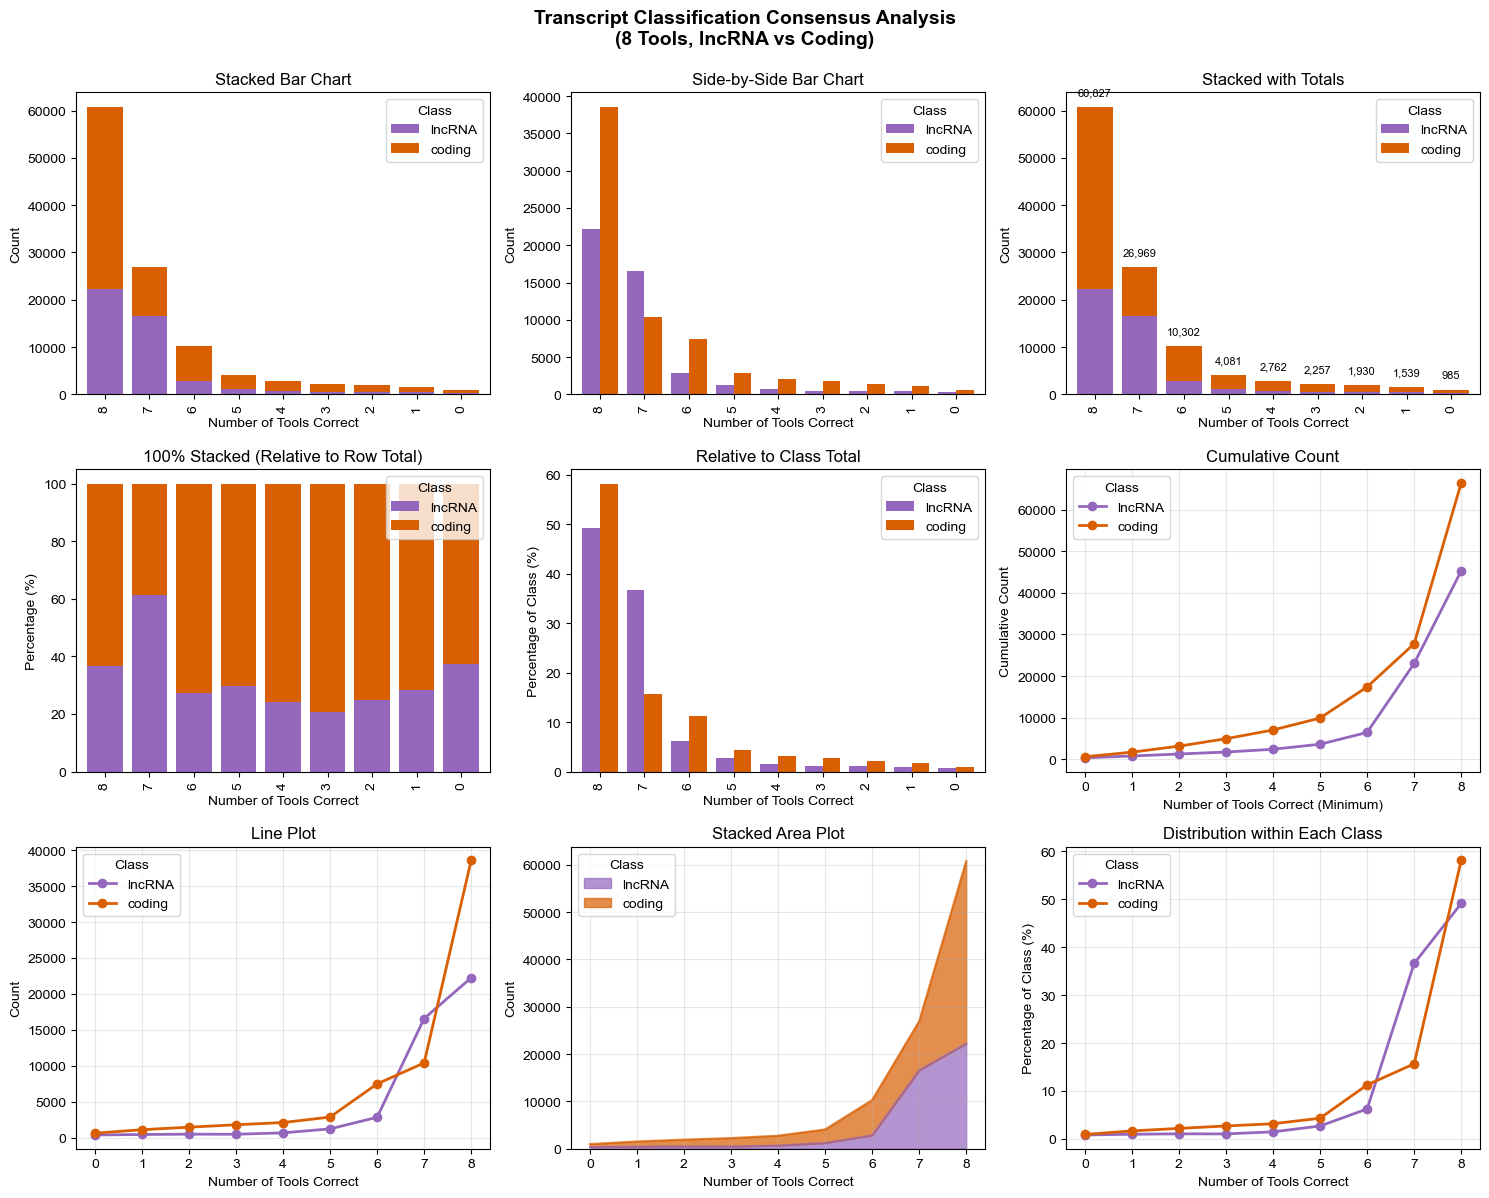


Summary Statistics:
Total transcripts: 111,652
Total lncRNA: 45,276
Total coding: 66,376

Perfect consensus (8/8): 60,827 (54.5%)
High correctness (6-7/8): 37,271 (33.4%)
Wrong consensus (0/8): 985 (0.9%)


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Transcript Classification Consensus Analysis\n(8 Tools, lncRNA vs Coding)', 
             fontsize=14, fontweight='bold', y=0.995)

# Color scheme
colors = ['#9467bd', '#d95f02']  # lncRNA (purple), coding (orange)

# 1. Stacked bar chart
ax = axes[0, 0]
correct_by_class.plot.bar(stacked=True, ax=ax, color=colors, width=0.8)
ax.set_title('Stacked Bar Chart')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Count')
ax.legend(title='Class')

# 2. Side-by-side bar chart
ax = axes[0, 1]
correct_by_class.plot.bar(stacked=False, ax=ax, color=colors, width=0.8)
ax.set_title('Side-by-Side Bar Chart')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Count')
ax.legend(title='Class')

# 3. Stacked with total annotations
ax = axes[0, 2]
correct_by_class.plot.bar(stacked=True, ax=ax, color=colors, width=0.8)
totals = correct_by_class.sum(axis=1)
for i, (idx, total) in enumerate(totals.items()):
    ax.text(i, total + 2000, f'{total:,}', ha='center', va='bottom', fontsize=8)
ax.set_title('Stacked with Totals')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Count')
ax.legend(title='Class')

# 4. Relative to total (100% stacked)
ax = axes[1, 0]
correct_by_class_pct = correct_by_class.div(correct_by_class.sum(axis=1), axis=0) * 100
correct_by_class_pct.plot.bar(stacked=True, ax=ax, color=colors, width=0.8)
ax.set_title('100% Stacked (Relative to Row Total)')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Class')

# 5. Relative to class total
ax = axes[1, 1]
correct_by_class_class_pct = correct_by_class.div(correct_by_class.sum(axis=0), axis=1) * 100
correct_by_class_class_pct.plot.bar(stacked=False, ax=ax, color=colors, width=0.8)
ax.set_title('Relative to Class Total')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Percentage of Class (%)')
ax.legend(title='Class')

# 6. Cumulative plot
ax = axes[1, 2]
# Sort index in reverse order for cumulative sum from 8 to 0
correct_by_class_sorted = correct_by_class.sort_index(ascending=True)
cumulative = correct_by_class_sorted.cumsum()
cumulative.plot(ax=ax, marker='o', color=colors, linewidth=2, markersize=6)
ax.set_title('Cumulative Count')
ax.set_xlabel('Number of Tools Correct (Minimum)')
ax.set_ylabel('Cumulative Count')
ax.legend(title='Class')
ax.grid(True, alpha=0.3)

# 7. Line plot
ax = axes[2, 0]
correct_by_class.plot(ax=ax, marker='o', color=colors, linewidth=2, markersize=6)
ax.set_title('Line Plot')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Count')
ax.legend(title='Class')
ax.grid(True, alpha=0.3)

# 8. Area plot
ax = axes[2, 1]
correct_by_class.plot.area(ax=ax, color=colors, alpha=0.7)
ax.set_title('Stacked Area Plot')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)
ax.legend(title='Class')

# 9. Percentage line plot (relative to class total)
ax = axes[2, 2]
correct_by_class_class_pct.plot(ax=ax, marker='o', color=colors, linewidth=2, markersize=6)
ax.set_title('Distribution within Each Class')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Percentage of Class (%)')
ax.legend(title='Class')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Total transcripts: {correct_by_class.sum().sum():,}")
print(f"Total lncRNA: {correct_by_class['lncRNA'].sum():,}")
print(f"Total coding: {correct_by_class['coding'].sum():,}")
print(f"\nPerfect consensus (8/8): {correct_by_class.loc[8].sum():,} ({correct_by_class.loc[8].sum()/correct_by_class.sum().sum()*100:.1f}%)")
print(f"High correctness (6-7/8): {correct_by_class.loc[[6,7]].sum().sum():,} ({correct_by_class.loc[[6,7]].sum().sum()/correct_by_class.sum().sum()*100:.1f}%)")
print(f"Wrong consensus (0/8): {correct_by_class.loc[0].sum():,} ({correct_by_class.loc[0].sum()/correct_by_class.sum().sum()*100:.1f}%)")

In [ ]:
correct_by_class.loc[[6,7]].sum().sum()

np.int64(37271)

## All, none and ambiguous

In [ ]:
all_or_none = pd.DataFrame(columns=correct_by_class.columns)
all_or_none.loc["None"] = correct_by_class.loc[0]
all_or_none.loc["All"] = correct_by_class.loc[8]
all_or_none.loc["Ambiguous"] = correct_by_class.loc[list(range(1,8))].sum()
all_or_none["order"] = [2, 0, 1]
all_or_none = all_or_none.sort_values("order").drop(columns="order")
all_or_none

real,lncRNA,coding
All,22240,38587
Ambiguous,22668,27172
None,368,617


/tmp/ipykernel_3106561/2171474402.py:91: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


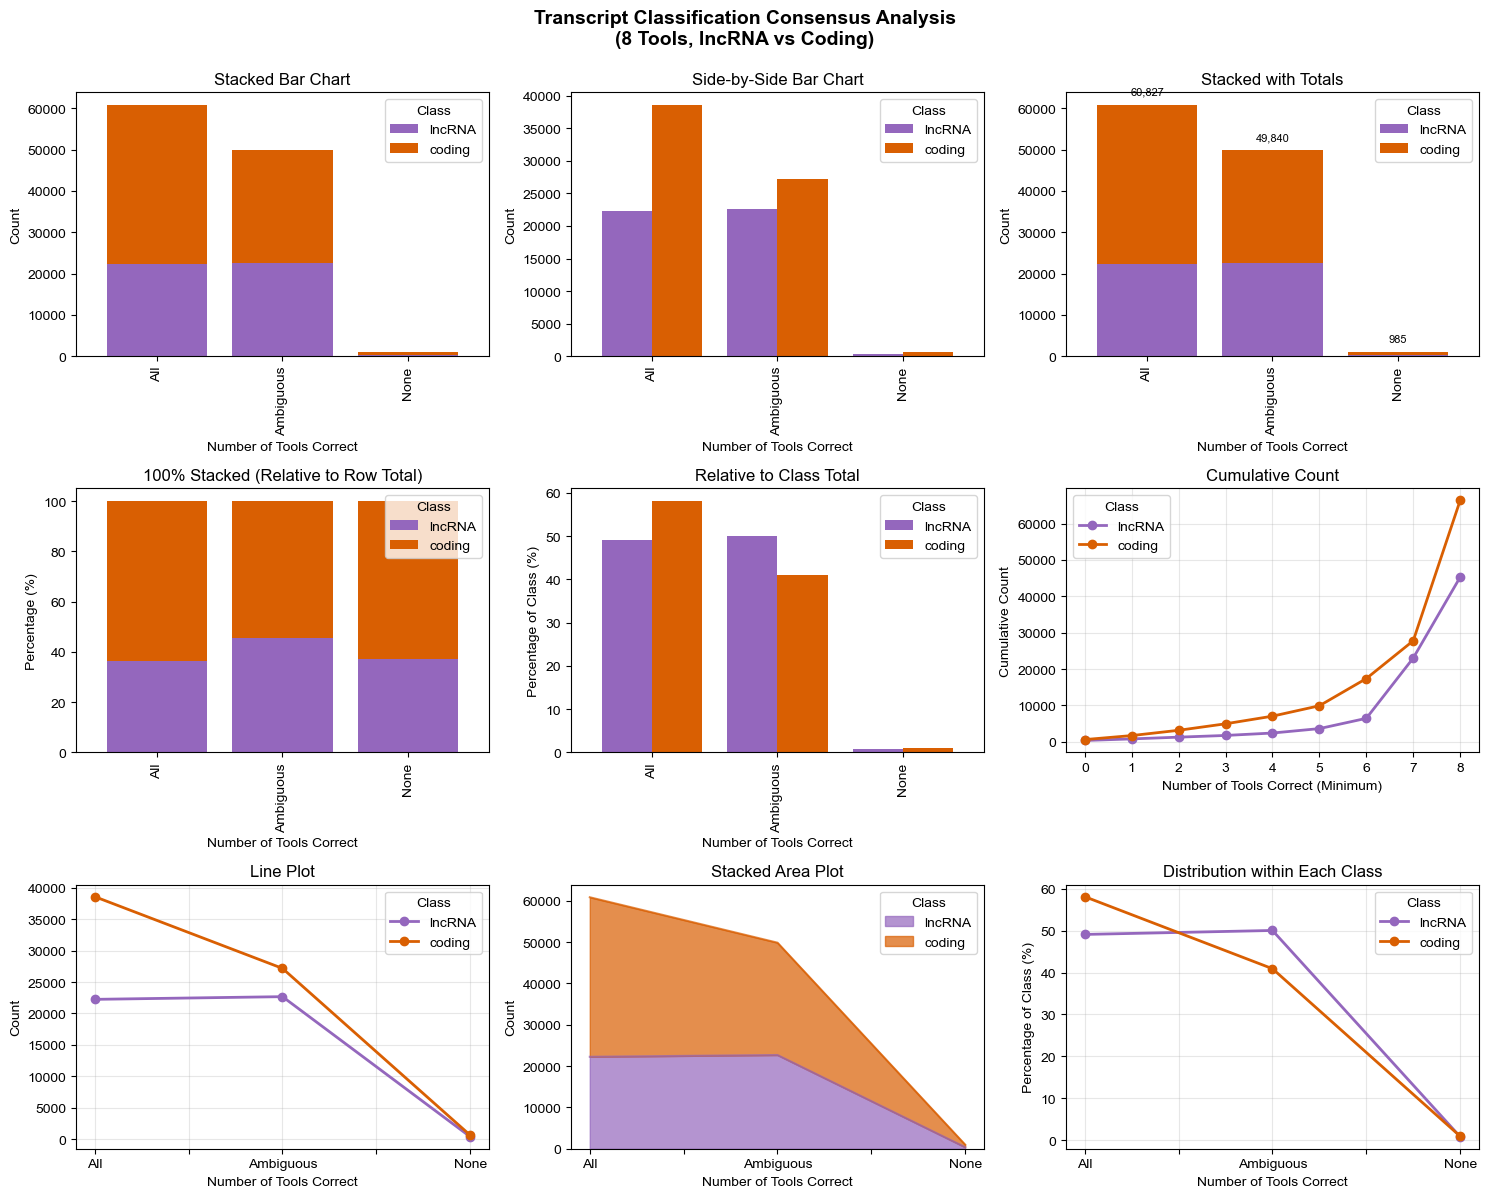


Summary Statistics:
Total transcripts: 111,652
Total lncRNA: 45,276
Total coding: 66,376

Perfect consensus (8/8): 60,827 (54.5%)
No consensus (0/8): 985 (0.9%)


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Transcript Classification Consensus Analysis\n(8 Tools, lncRNA vs Coding)', 
             fontsize=14, fontweight='bold', y=0.995)

# Color scheme
colors = ['#9467bd', '#d95f02']  # lncRNA (purple), coding (orange)

# 1. Stacked bar chart
ax = axes[0, 0]
all_or_none.plot.bar(stacked=True, ax=ax, color=colors, width=0.8)
ax.set_title('Stacked Bar Chart')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Count')
ax.legend(title='Class')

# 2. Side-by-side bar chart
ax = axes[0, 1]
all_or_none.plot.bar(stacked=False, ax=ax, color=colors, width=0.8)
ax.set_title('Side-by-Side Bar Chart')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Count')
ax.legend(title='Class')

# 3. Stacked with total annotations
ax = axes[0, 2]
all_or_none.plot.bar(stacked=True, ax=ax, color=colors, width=0.8)
totals = all_or_none.sum(axis=1)
for i, (idx, total) in enumerate(totals.items()):
    ax.text(i, total + 2000, f'{total:,}', ha='center', va='bottom', fontsize=8)
ax.set_title('Stacked with Totals')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Count')
ax.legend(title='Class')

# 4. Relative to total (100% stacked)
ax = axes[1, 0]
all_or_none_pct = all_or_none.div(all_or_none.sum(axis=1), axis=0) * 100
all_or_none_pct.plot.bar(stacked=True, ax=ax, color=colors, width=0.8)
ax.set_title('100% Stacked (Relative to Row Total)')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Class')

# 5. Relative to class total
ax = axes[1, 1]
all_or_none_class_pct = all_or_none.div(all_or_none.sum(axis=0), axis=1) * 100
all_or_none_class_pct.plot.bar(stacked=False, ax=ax, color=colors, width=0.8)
ax.set_title('Relative to Class Total')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Percentage of Class (%)')
ax.legend(title='Class')

# 6. Cumulative plot
ax = axes[1, 2]
# Sort index in reverse order for cumulative sum from 8 to 0
correct_by_class_sorted = correct_by_class.sort_index(ascending=True)
cumulative = correct_by_class_sorted.cumsum()
cumulative.plot(ax=ax, marker='o', color=colors, linewidth=2, markersize=6)
ax.set_title('Cumulative Count')
ax.set_xlabel('Number of Tools Correct (Minimum)')
ax.set_ylabel('Cumulative Count')
ax.legend(title='Class')
ax.grid(True, alpha=0.3)

# 7. Line plot
ax = axes[2, 0]
all_or_none.plot(ax=ax, marker='o', color=colors, linewidth=2, markersize=6)
ax.set_title('Line Plot')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Count')
ax.legend(title='Class')
ax.grid(True, alpha=0.3)

# 8. Area plot
ax = axes[2, 1]
all_or_none.plot.area(ax=ax, color=colors, alpha=0.7)
ax.set_title('Stacked Area Plot')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Count')
ax.legend(title='Class')

# 9. Percentage line plot (relative to class total)
ax = axes[2, 2]
all_or_none_class_pct.plot(ax=ax, marker='o', color=colors, linewidth=2, markersize=6)
ax.set_title('Distribution within Each Class')
ax.set_xlabel('Number of Tools Correct')
ax.set_ylabel('Percentage of Class (%)')
ax.legend(title='Class')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Total transcripts: {all_or_none.sum().sum():,}")
print(f"Total lncRNA: {all_or_none['lncRNA'].sum():,}")
print(f"Total coding: {all_or_none['coding'].sum():,}")
print(f"\nPerfect consensus (8/8): {all_or_none.loc["All"].sum():,} ({all_or_none.loc["All"].sum()/all_or_none.sum().sum()*100:.1f}%)")
print(f"No consensus (0/8): {all_or_none.loc["None"].sum():,} ({all_or_none.loc["None"].sum()/all_or_none.sum().sum()*100:.1f}%)")

## Final plot

In [ ]:
all_or_none.sum(axis=1)

All          60827
Ambiguous    49840
None           985
dtype: int64

DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/home/dgarcia/.local/share/fonts/Arial.TTF'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /home/dgarcia/.local/share/fonts/Arial.TTF.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.
DEBUG:matplotlib.backends.backend_pdf:SUBSET /home/dgarcia/.local/share/fonts/Arial.TTF characters:  %().012³45689ANRTabcdefgilmnoprstux
DEBUG:fontTools.subset.timer:Took 0.001s to load font
DEBUG:fontTools.ttLib.ttFont:Reading 'maxp' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'maxp' table
DEBUG:fontTools.subset.timer:Took 0.002s to load 'maxp'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'maxp'
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
DEBUG:fontTools.ttLib.ttFont:Reading 'cmap' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'cmap' table
DEBUG:fontTools.subset.timer:Took 0.001s to load 'cmap'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'cmap'
INFO:fontTools.subset:cm

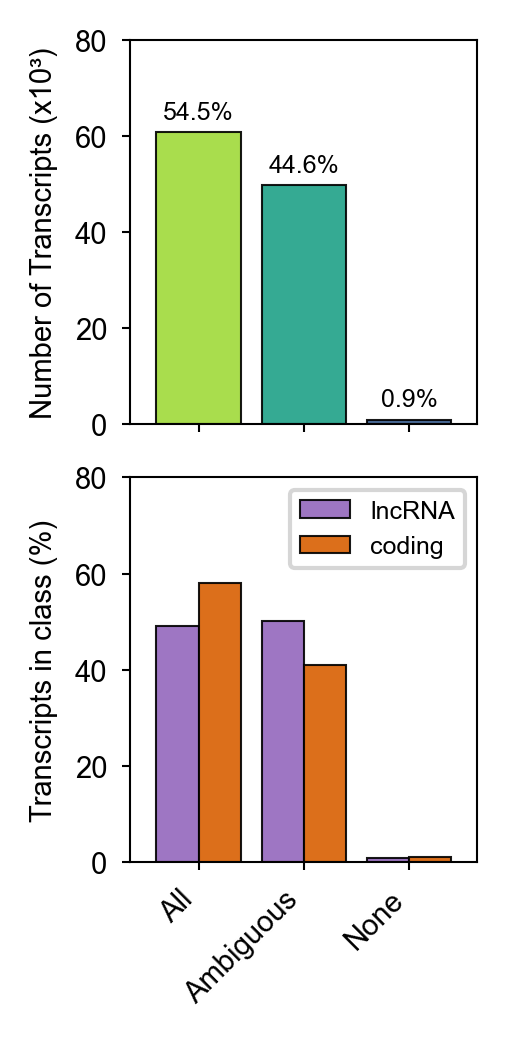

In [ ]:
import utils.plotting

fig_width_cm = 4
fig_height_cm = 8.5

# Configure default line width and font weight
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5

plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'normal'

plt.rcParams['axes.titlesize'] = 9
plt.rcParams['axes.labelsize'] = 7
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['lines.markersize'] = 5
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7

# Default param for text annotations
plt.rcParams['font.size'] = 6
plt.rcParams['legend.fontsize'] = 6


fig, axes = plt.subplots(2, 1, figsize=(fig_width_cm/2.54, fig_height_cm/2.54), dpi=300, sharex=True)
#fig.suptitle('Classification consensus analysis', fontsize=12, fontweight='bold', y=0.995)

viridis = plt.get_cmap('viridis', 8)
vir_colors = [viridis(6), viridis(4), viridis(2)]

all_or_none_total = all_or_none.sum(axis=1) / 1000
all_or_none_total.plot.bar(ax=axes[0], color=vir_colors, width=0.8, alpha=0.9, edgecolor='black', linewidth=0.5)
#axes[0].set_title('Total Transcripts')
#axes[0].set_xlabel('Number of Tools Correct')
axes[0].set_ylabel('Number of Transcripts (x10³)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticks(np.arange(0, all_or_none_total.max() + 20, 20))
axes[0].set_ylim(0, 80)
axes[0].tick_params(axis='y')

# Add percentage annotations on top of bars
total_transcripts = all_or_none.sum().sum() / 1000
for container in axes[0].containers:
    for bar in container:
        height = bar.get_height()
        if np.isfinite(height) and height > 0:
            axes[0].annotate(
                f'{height/total_transcripts*100:.1f}%',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center',
                va='bottom',
                xytext=(0, 2),
                textcoords='offset points'
            )

all_or_none_class_pct = all_or_none.div(all_or_none.sum(axis=0), axis=1) * 100
all_or_none_class_pct.plot.bar(stacked=False, ax=axes[1], color=colors, width=0.8, alpha=0.9, edgecolor='black', linewidth=0.5)
#axes[1].set_title('Relative to coding class')
#axes[1].set_xlabel('Number of Tools Correct')
axes[1].set_ylabel('Transcripts in class (%)')
axes[1].legend(title='')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticks(np.arange(0, all_or_none_total.max() + 20, 20))
axes[1].set_ylim(0, 80)
axes[1].tick_params(axis='y')

for ax in axes:
    ax.tick_params(width=0.5, length=2)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

plt.savefig(os.path.join(FIGURE_DIR, "correct_classification.pdf"), dpi=300, format="pdf")
plt.show()
plt.show()
